# Precision, Recall e a Curva PR
## Por que não basta usar acurácia em detecção de fraudes?

---

Este notebook explica do zero os conceitos de **Matriz de Confusão**, **Precision**, **Recall** e **Curva Precision-Recall**, e por que precisamos de uma **função de threshold** no nosso pipeline de fraude.

---
## 1. O Problema da Acurácia em Datasets Desbalanceados

Imagine que você tem **1.000.000 transações** e apenas **5.000 são fraudes** (0,5%).

Um modelo burro que **sempre prevê "não é fraude"** teria:

$$\text{Acurácia} = \frac{\text{Acertos}}{\text{Total}} = \frac{995.000}{1.000.000} = 99{,}5\%$$

99,5% de acurácia — e o modelo **nunca detecta uma única fraude**.

Por isso acurácia é **inútil** como métrica principal em detecção de fraudes. Precisamos de outras métricas.

---
## 2. A Matriz de Confusão

A matriz de confusão organiza os resultados de um classificador em 4 categorias:

```
                    PREDIÇÃO DO MODELO
                  ┌─────────────┬─────────────┐
                  │ Previu      │ Previu      │
                  │ NÃO FRAUDE  │ FRAUDE      │
      ┌───────────┼─────────────┼─────────────┤
      │ Real:     │             │             │
REAL  │ NÃO FRAUDE│ TN          │ FP          │
      ├───────────┼─────────────┼─────────────┤
      │ Real:     │             │             │
      │ FRAUDE    │ FN          │ TP          │
      └───────────┴─────────────┴─────────────┘
```

| Sigla | Nome | Tradução | O que significa |
|---|---|---|---|
| **TP** | True Positive | Verdadeiro Positivo | Era fraude, model disse fraude ✅ |
| **TN** | True Negative | Verdadeiro Negativo | Não era fraude, modelo disse não fraude ✅ |
| **FP** | False Positive | Falso Positivo | **Não era fraude, mas modelo disse fraude ❌** (alarme falso) |
| **FN** | False Negative | Falso Negativo | **Era fraude, mas modelo disse não fraude ❌** (fraude escapou) |

### Qual erro é pior?

Depende do contexto:
- **FP alto:** bloqueamos muitas transações legítimas → cliente furioso, ligando pro banco
- **FN alto:** deixamos fraudes passarem → prejuízo financeiro para o banco

No nosso projeto, queremos **minimizar FN** (detectar o máximo de fraudes) **sem explodir os FP** (sem bloquear clientes inocentes o tempo todo).

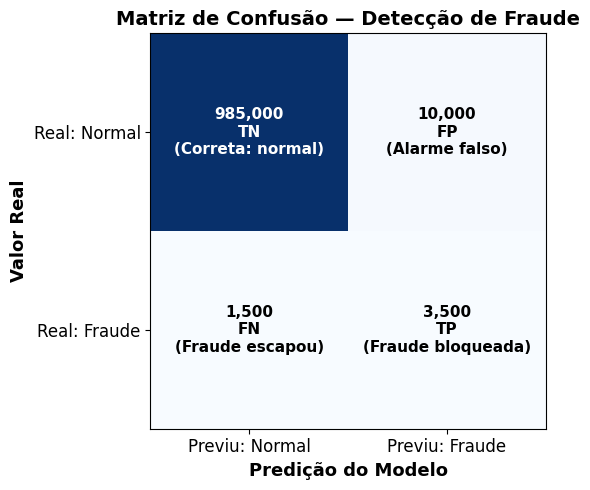


Total de transações: 1,000,000
Fraudes reais:       5,000 (0.5%)
Acurácia (inútil):   98.85%


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Simulação de uma matriz de confusão realista
# Dataset: 1M transações, 0.5% fraude = 5000 fraudes e 995000 normais
TN = 985000   # transações normais corretamente identificadas
FP = 10000    # transações normais bloqueadas erroneamente (alarme falso)
FN = 1500     # fraudes que escaparam (não detectadas)
TP = 3500     # fraudes corretamente bloqueadas

cm = np.array([[TN, FP],
               [FN, TP]])

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(cm, interpolation='nearest', cmap='Blues')

labels = [['TN\n(Correta: normal)', 'FP\n(Alarme falso)'],
          ['FN\n(Fraude escapou)', 'TP\n(Fraude bloqueada)']]

for i in range(2):
    for j in range(2):
        color = 'white' if cm[i, j] > cm.max() / 2 else 'black'
        ax.text(j, i, f'{cm[i, j]:,}\n{labels[i][j]}',
                ha='center', va='center', fontsize=11, color=color, fontweight='bold')

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Previu: Normal', 'Previu: Fraude'], fontsize=12)
ax.set_yticklabels(['Real: Normal', 'Real: Fraude'], fontsize=12)
ax.set_xlabel('Predição do Modelo', fontsize=13, fontweight='bold')
ax.set_ylabel('Valor Real', fontsize=13, fontweight='bold')
ax.set_title('Matriz de Confusão — Detecção de Fraude', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\nTotal de transações: {TN+FP+FN+TP:,}')
print(f'Fraudes reais:       {FN+TP:,} ({(FN+TP)/(TN+FP+FN+TP):.1%})')
print(f'Acurácia (inútil):   {(TN+TP)/(TN+FP+FN+TP):.2%}')

---
## 3. O que é Precision?

**Precision** responde à pergunta:

> "Das transações que o modelo **acusou de fraude**, quantas eram de fato fraudes?"

$$\text{Precision} = \frac{TP}{TP + FP}$$

### Interpretação intuitiva

Pense na Precision como a **confiança das acusações do modelo**.

- **Precision = 1.0:** toda transação que o modelo bloqueou era de fato uma fraude. Zero alarmes falsos.
- **Precision = 0.5:** metade das transações bloqueadas eram legítimas. Para cada fraude bloqueada, um cliente inocente foi incomodado.
- **Precision = 0.1:** 90% das transações bloqueadas eram legítimas. Caos total.

No nosso projeto, exigimos **Precision ≥ 0.90**: no máximo 10% das transações bloqueadas podem ser alarmes falsos.

In [4]:
precision = TP / (TP + FP)
print(f'TP (fraudes bloqueadas):  {TP:,}')
print(f'FP (alarmes falsos):      {FP:,}')
print(f'TP + FP (total bloqueado):{TP+FP:,}')
print()
print(f'Precision = {TP} / ({TP} + {FP}) = {TP}/{TP+FP} = {precision:.2%}')
print()
if precision >= 0.90:
    print('OK: Precision >= 90% — acusações confiáveis')
else:
    print('ATENCAO: Precision < 90% — muitos alarmes falsos')

# Interpretação em linguagem de negócio
print(f'\nA cada 100 transacoes bloqueadas:')
print(f'  {precision*100:.0f} eram realmente fraudes')
print(f'  {(1-precision)*100:.0f} eram transacoes legitimas bloqueadas por engano')

TP (fraudes bloqueadas):  3,500
FP (alarmes falsos):      10,000
TP + FP (total bloqueado):13,500

Precision = 3500 / (3500 + 10000) = 3500/13500 = 25.93%

ATENCAO: Precision < 90% — muitos alarmes falsos

A cada 100 transacoes bloqueadas:
  26 eram realmente fraudes
  74 eram transacoes legitimas bloqueadas por engano


---
## 4. O que é Recall?

**Recall** (também chamado de **Sensibilidade** ou **True Positive Rate**) responde à pergunta:

> "De todas as fraudes que **realmente existiram**, quantas o modelo conseguiu detectar?"

$$\text{Recall} = \frac{TP}{TP + FN}$$

### Interpretação intuitiva

Pense no Recall como a **cobertura do modelo** sobre as fraudes reais.

- **Recall = 1.0:** nenhuma fraude escapou. O modelo detectou 100% das fraudes.
- **Recall = 0.7:** 70% das fraudes foram detectadas. 30% passaram despercebidas.
- **Recall = 0.1:** o modelo deixou 90% das fraudes passarem. Inútil.

### O trade-off fundamental

**Precision e Recall estão em conflito direto:**

- Se você quer **maximizar Recall** (detectar todas as fraudes), você abaixa o threshold → o modelo acusa tudo que parece minimamente suspeito → muitos FP → **Precision cai**
- Se você quer **maximizar Precision** (só acusar quando tem certeza), você sobe o threshold → o modelo só acusa casos óbvios → muitas fraudes escapam → **Recall cai**

Não existe almoço grátis: você precisa escolher qual equilibrio faz sentido para o seu negócio.

In [5]:
recall = TP / (TP + FN)
print(f'TP (fraudes detectadas):  {TP:,}')
print(f'FN (fraudes escapadas):   {FN:,}')
print(f'Total fraudes reais:      {TP+FN:,}')
print()
print(f'Recall = {TP} / ({TP} + {FN}) = {TP}/{TP+FN} = {recall:.2%}')
print()
print(f'A cada 100 fraudes reais:')
print(f'  {recall*100:.0f} foram detectadas e bloqueadas')
print(f'  {(1-recall)*100:.0f} escaparam e causaram prejuizo')

# F1-Score: media harmonica entre Precision e Recall
f1 = 2 * (precision * recall) / (precision + recall)
print(f'\nF1-Score (media harmonica): {f1:.2%}')
print('O F1-Score equilibra Precision e Recall em um unico numero.')

TP (fraudes detectadas):  3,500
FN (fraudes escapadas):   1,500
Total fraudes reais:      5,000

Recall = 3500 / (3500 + 1500) = 3500/5000 = 70.00%

A cada 100 fraudes reais:
  70 foram detectadas e bloqueadas
  30 escaparam e causaram prejuizo

F1-Score (media harmonica): 37.84%
O F1-Score equilibra Precision e Recall em um unico numero.


---
## 5. Visualizando o Trade-off: Precision vs Recall

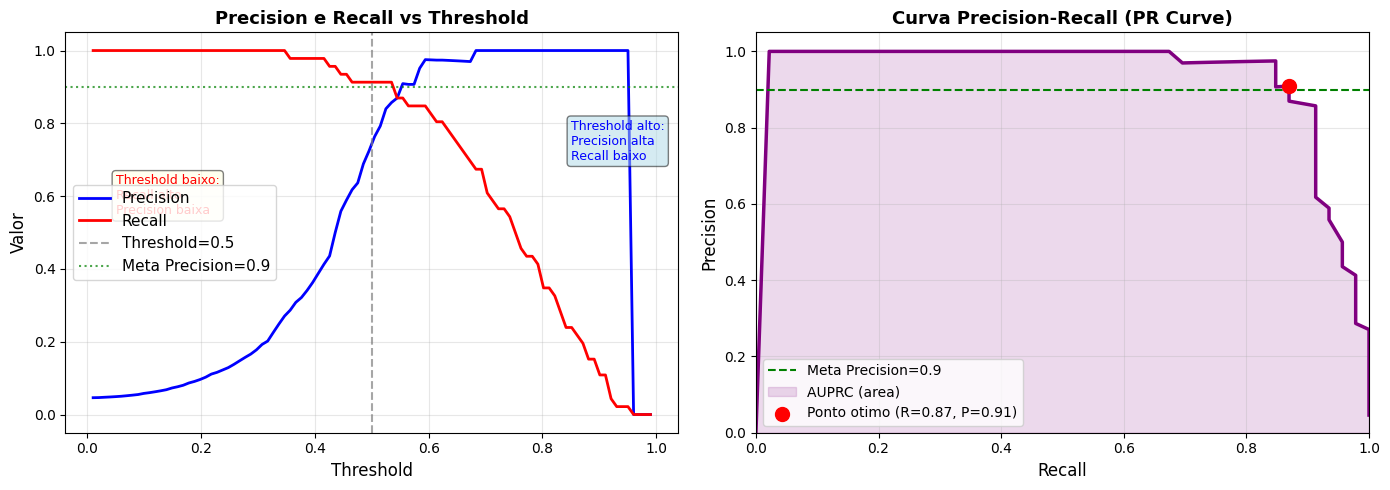

In [6]:
# Simulação do trade-off com diferentes thresholds
np.random.seed(42)
n = 1000
# 5% de fraudes
y_true = np.random.binomial(1, 0.05, n)
# Probabilidades simuladas: fraudes tendem a ter score mais alto
y_scores = np.where(y_true == 1,
                    np.random.beta(5, 2, n),   # fraudes: distribuição com media ~0.71
                    np.random.beta(2, 8, n))   # normais: distribuição com media ~0.20

thresholds = np.linspace(0.01, 0.99, 100)
precisions = []
recalls = []

for thr in thresholds:
    y_pred = (y_scores >= thr).astype(int)
    tp = ((y_pred == 1) & (y_true == 1)).sum()
    fp = ((y_pred == 1) & (y_true == 0)).sum()
    fn = ((y_pred == 0) & (y_true == 1)).sum()
    p = tp / max(1, tp + fp)
    r = tp / max(1, tp + fn)
    precisions.append(p)
    recalls.append(r)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Precision e Recall vs Threshold
axes[0].plot(thresholds, precisions, 'b-', linewidth=2, label='Precision')
axes[0].plot(thresholds, recalls, 'r-', linewidth=2, label='Recall')
axes[0].axvline(x=0.5, color='gray', linestyle='--', alpha=0.7, label='Threshold=0.5')
axes[0].axhline(y=0.9, color='green', linestyle=':', alpha=0.7, label='Meta Precision=0.9')
axes[0].set_xlabel('Threshold', fontsize=12)
axes[0].set_ylabel('Valor', fontsize=12)
axes[0].set_title('Precision e Recall vs Threshold', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].annotate('Threshold alto:\nPrecision alta\nRecall baixo',
                 xy=(0.85, 0.7), fontsize=9, color='blue',
                 bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))
axes[0].annotate('Threshold baixo:\nRecall alto\nPrecision baixa',
                 xy=(0.05, 0.55), fontsize=9, color='red',
                 bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.5))

# Gráfico 2: Curva Precision-Recall
axes[1].plot(recalls, precisions, 'purple', linewidth=2.5)
axes[1].axhline(y=0.9, color='green', linestyle='--', linewidth=1.5, label='Meta Precision=0.9')
axes[1].fill_between(recalls, precisions, alpha=0.15, color='purple', label='AUPRC (area)')
axes[1].set_xlabel('Recall', fontsize=12)
axes[1].set_ylabel('Precision', fontsize=12)
axes[1].set_title('Curva Precision-Recall (PR Curve)', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1.05])

# Marca o ponto ideal: maior recall com precision >= 0.9
validos = [(r, p) for r, p in zip(recalls, precisions) if p >= 0.9]
if validos:
    best_r, best_p = max(validos, key=lambda x: x[0])
    axes[1].scatter([best_r], [best_p], color='red', s=100, zorder=5,
                    label=f'Ponto otimo (R={best_r:.2f}, P={best_p:.2f})')
    axes[1].legend(fontsize=10)

plt.tight_layout()
plt.show()

---
## 6. A Curva Precision-Recall e o AUPRC

A **Curva Precision-Recall** é gerada variando o threshold de 0 a 1 e calculando Precision e Recall em cada ponto.

O **AUPRC** (Area Under the Precision-Recall Curve) é a **área sob essa curva** — um único número que resume a qualidade do modelo:

| AUPRC | Interpretação |
|---|---|
| ≈ taxa de fraude (ex: 0.005) | Modelo aleatório (péssimo) |
| 0.5 | Modelo razoável |
| 0.8+ | Modelo bom |
| 0.95+ | Modelo excelente |

### Por que AUPRC e não AUROC para fraudes?

**AUROC** (Area Under the ROC Curve) é insensível ao desbalanceamento de classes. Em um dataset com 0.5% de fraudes, um modelo ruim ainda pode ter AUROC de 0.97 simplesmente porque existem muitos verdadeiros negativos fáceis de classificar.

**AUPRC** foca nas classes positivas (fraudes) e penaliza diretamente quando o modelo erra nelas. É muito mais informativo quando as classes são desbalanceadas.

In [7]:
from sklearn.metrics import average_precision_score, roc_auc_score, precision_recall_curve

auprc = average_precision_score(y_true, y_scores)
auroc = roc_auc_score(y_true, y_scores)

print(f'AUPRC: {auprc:.4f}')
print(f'AUROC: {auroc:.4f}')
print()
print('O AUPRC e a metrica principal do nosso pipeline MLOps.')
print('Ela mede quanto o modelo e capaz de manter alta Precision')
print('enquanto aumenta o Recall — o equilibrio ideal para fraude.')

AUPRC: 0.9405
AUROC: 0.9938

O AUPRC e a metrica principal do nosso pipeline MLOps.
Ela mede quanto o modelo e capaz de manter alta Precision
enquanto aumenta o Recall — o equilibrio ideal para fraude.


---
## 7. Por que Criamos uma Função de Threshold?

O modelo de machine learning **não prevê diretamente "fraude" ou "não fraude"** — ele prevê uma **probabilidade** entre 0 e 1:

```
Transação A → modelo → 0.03  (3% de chance de fraude → provavelmente normal)
Transação B → modelo → 0.73  (73% de chance de fraude → suspeita)
Transação C → modelo → 0.97  (97% de chance de fraude → quase certeza)
```

Precisamos de um **ponto de corte (threshold)** para converter a probabilidade em decisão binária:

$$\text{Decisão} = \begin{cases} \text{FRAUDE} & \text{se } P(\text{fraude}) \geq \theta \\ \text{NORMAL} & \text{se } P(\text{fraude}) < \theta \end{cases}$$

### O problema com threshold = 0.5 (padrão)

A maioria dos modelos usa threshold = 0.5 por padrão. Mas esse valor **ignora o custo de negócio**:

- Com 0.5, o modelo pode ter Precision de apenas 60% → 40% de alarmes falsos → inaceitável
- Com 0.5, o modelo pode ter Precision de 99% mas Recall de 10% → deixa 90% das fraudes passarem

### A solução: selecionar o threshold ótimo automaticamente

A função `pick_threshold_for_precision()` do `train.py` faz isso:

```python
def pick_threshold_for_precision(y_true, y_prob, target_precision=0.90):
    precision, recall, thresholds = precision_recall_curve(y_true, y_prob)
    
    best_thr = 0.5      # fallback
    best_recall = -1.0  # queremos maximizar o recall
    
    for p, r, t in zip(precision[:-1], recall[:-1], thresholds):
        if p >= target_precision and r > best_recall:
            best_recall = r
            best_thr = float(t)
    
    return best_thr
```

**Objetivo:** encontrar o threshold que **maximiza o Recall** mantendo **Precision ≥ 90%**.

Em linguagem de negócio: *"Detecte o máximo de fraudes possível, mas só bloqueie quando tiver pelo menos 90% de certeza."*

In [8]:
def pick_threshold_for_precision(y_true, y_prob, target_precision=0.90):
    """Encontra o threshold que maximiza Recall com Precision >= target_precision."""
    precision_vals, recall_vals, thr_vals = precision_recall_curve(y_true, y_prob)
    
    best_thr = 0.5
    best_recall = -1.0
    
    for p, r, t in zip(precision_vals[:-1], recall_vals[:-1], thr_vals):
        if p >= target_precision and r > best_recall:
            best_recall = r
            best_thr = float(t)
    
    return best_thr

# Comparação: threshold padrão vs threshold otimizado
thr_default = 0.5
thr_otimo = pick_threshold_for_precision(y_true, y_scores, target_precision=0.90)

def calcular_metricas(y_true, y_scores, thr):
    y_pred = (y_scores >= thr).astype(int)
    tp = ((y_pred == 1) & (y_true == 1)).sum()
    fp = ((y_pred == 1) & (y_true == 0)).sum()
    fn = ((y_pred == 0) & (y_true == 1)).sum()
    tn = ((y_pred == 0) & (y_true == 0)).sum()
    p = tp / max(1, tp + fp)
    r = tp / max(1, tp + fn)
    return {'TP': tp, 'FP': fp, 'FN': fn, 'TN': tn,
            'Precision': p, 'Recall': r}

m_default = calcular_metricas(y_true, y_scores, thr_default)
m_otimo   = calcular_metricas(y_true, y_scores, thr_otimo)

print(f'Threshold padrão (0.50)       | Threshold otimizado ({thr_otimo:.2f})')
print('-' * 65)
for k in ['Precision', 'Recall', 'TP', 'FP', 'FN']:
    v_def = m_default[k]
    v_ot  = m_otimo[k]
    if isinstance(v_def, float):
        print(f'{k:<12}: {v_def:.2%}              | {v_ot:.2%}')
    else:
        print(f'{k:<12}: {v_def:<22} | {v_ot}')

print()
print(f'Com o threshold otimizado:')
print(f'  Precision: {m_otimo["Precision"]:.0%} (cumpre a meta de 90%)')
print(f'  Recall:    {m_otimo["Recall"]:.0%} (detecta mais fraudes que o threshold padrao)')

Threshold padrão (0.50)       | Threshold otimizado (0.56)
-----------------------------------------------------------------
Precision   : 75.00%              | 90.91%
Recall      : 91.30%              | 86.96%
TP          : 42                     | 40
FP          : 14                     | 4
FN          : 4                      | 6

Com o threshold otimizado:
  Precision: 91% (cumpre a meta de 90%)
  Recall:    87% (detecta mais fraudes que o threshold padrao)


---
## 8. Visualização Completa: Threshold Ótimo na Curva PR

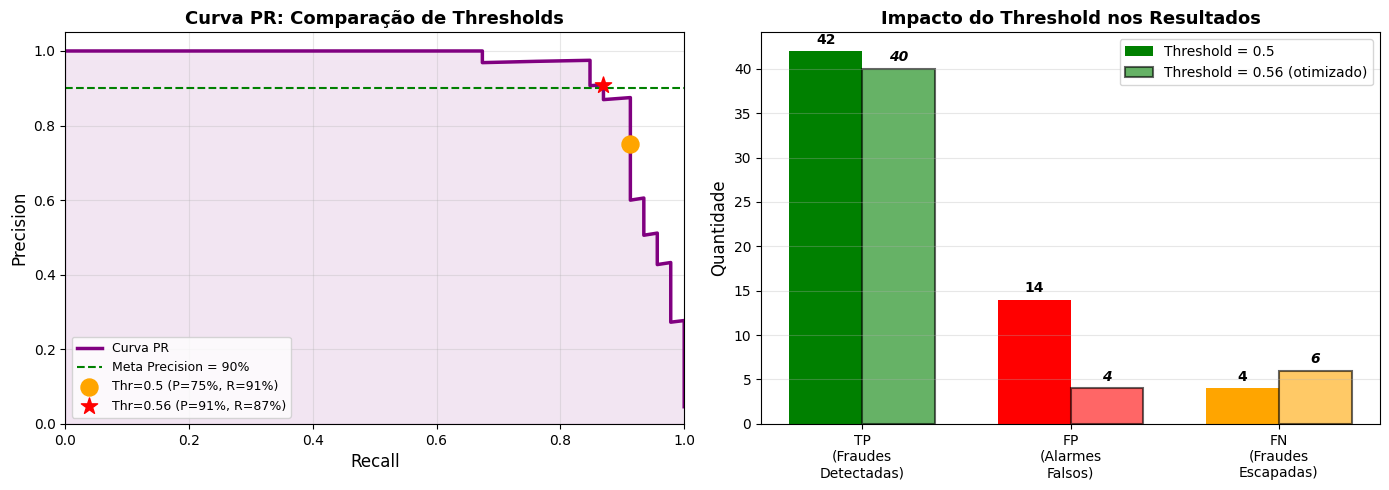

In [9]:
precision_vals, recall_vals, thr_vals = precision_recall_curve(y_true, y_scores)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Curva PR com threshold default e otimizado marcados
axes[0].plot(recall_vals, precision_vals, 'purple', linewidth=2.5, label='Curva PR')
axes[0].axhline(y=0.9, color='green', linestyle='--', linewidth=1.5,
                label='Meta Precision = 90%')
axes[0].fill_between(recall_vals, precision_vals, alpha=0.1, color='purple')

# Ponto com threshold padrão
axes[0].scatter([m_default['Recall']], [m_default['Precision']],
                color='orange', s=150, zorder=5,
                label=f'Thr=0.5 (P={m_default["Precision"]:.0%}, R={m_default["Recall"]:.0%})')

# Ponto com threshold otimizado
axes[0].scatter([m_otimo['Recall']], [m_otimo['Precision']],
                color='red', s=150, zorder=5, marker='*',
                label=f'Thr={thr_otimo:.2f} (P={m_otimo["Precision"]:.0%}, R={m_otimo["Recall"]:.0%})')

axes[0].set_xlabel('Recall', fontsize=12)
axes[0].set_ylabel('Precision', fontsize=12)
axes[0].set_title('Curva PR: Comparação de Thresholds', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim([0, 1])
axes[0].set_ylim([0, 1.05])

# Gráfico 2: Comparação visual das matrizes de confusão
categorias = ['TP\n(Fraudes\nDetectadas)', 'FP\n(Alarmes\nFalsos)', 'FN\n(Fraudes\nEscapadas)']
vals_default = [m_default['TP'], m_default['FP'], m_default['FN']]
vals_otimo   = [m_otimo['TP'],   m_otimo['FP'],   m_otimo['FN']]

x = np.arange(len(categorias))
width = 0.35
bars1 = axes[1].bar(x - width/2, vals_default, width, label='Threshold = 0.5',
                    color=['green', 'red', 'orange'])
bars2 = axes[1].bar(x + width/2, vals_otimo, width, label=f'Threshold = {thr_otimo:.2f} (otimizado)',
                    color=['green', 'red', 'orange'], alpha=0.6, edgecolor='black', linewidth=1.5)

for bar in bars1:
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
                 str(int(bar.get_height())), ha='center', va='bottom', fontweight='bold')
for bar in bars2:
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
                 str(int(bar.get_height())), ha='center', va='bottom', fontweight='bold', style='italic')

axes[1].set_xticks(x)
axes[1].set_xticklabels(categorias, fontsize=10)
axes[1].set_ylabel('Quantidade', fontsize=12)
axes[1].set_title('Impacto do Threshold nos Resultados', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

---
## 9. Resumo Final

| Conceito | Fórmula | Pergunta respondida | O que penaliza |
|---|---|---|---|
| **Precision** | TP / (TP + FP) | Das acusações, quantas eram fraudes? | Alarmes falsos (FP) |
| **Recall** | TP / (TP + FN) | Das fraudes reais, quantas detectamos? | Fraudes escapadas (FN) |
| **F1-Score** | 2·P·R / (P+R) | Equilíbrio geral entre P e R | FP e FN igualmente |
| **AUPRC** | Área sob curva PR | Qualidade geral em todos os thresholds | Ruim desempenho em classes positivas |

### O pipeline do nosso projeto

```
1. Modelo XGBoost → produz probabilidades [0, 1] para cada transação

2. pick_threshold_for_precision(y_true, y_prob, target=0.90)
   → Varre a curva PR
   → Encontra o threshold que maximiza Recall com Precision >= 90%
   → Ex: threshold = 0.35

3. Em produção: if P(fraude) >= 0.35 → BLOQUEAR
                else                 → APROVAR

4. MLflow loga: auprc, auroc, precision_at_thr, recall_at_thr, threshold
```

O threshold selecionado é salvo no MLflow e pode ser recuperado junto com o modelo para garantir que a API de serving use exatamente o mesmo critério de decisão que foi validado no treinamento.